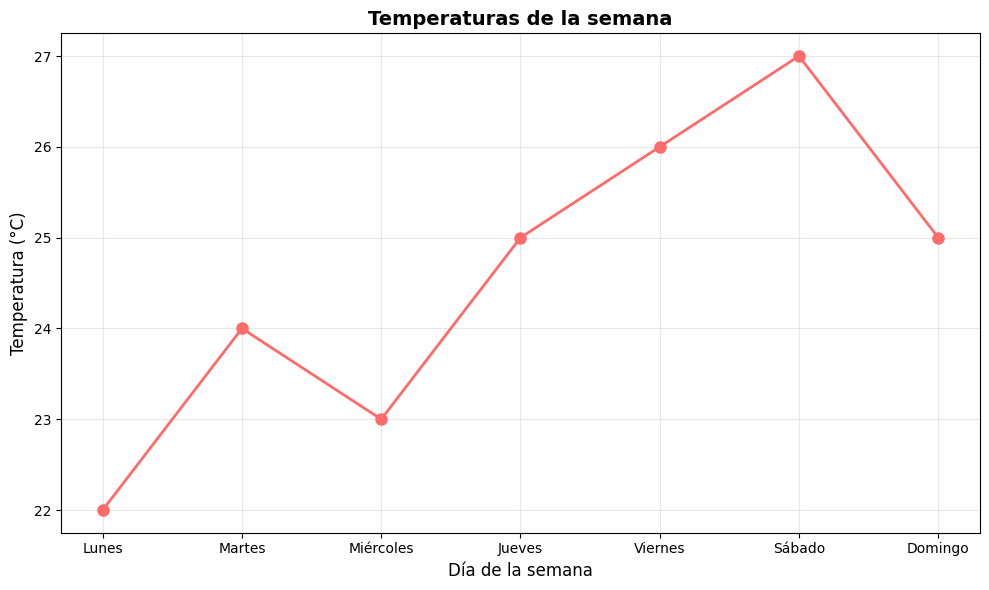

         Día  Temperatura (°C)
0      Lunes                22
1     Martes                24
2  Miércoles                23
3     Jueves                25
4    Viernes                26
5     Sábado                27
6    Domingo                25


In [5]:
import pandas as pd

import matplotlib.pyplot as plt

# Crear un conjunto de datos ficticio para las temperaturas de la semana.
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
temperaturas = [22, 24, 23, 25, 26, 27, 25]

# Convertir los datos en un DataFrame de Pandas, que facilita la manipulación y el análisis de datos tabulares.
df = pd.DataFrame({
    'Día': dias,
    'Temperatura (°C)': temperaturas
})

# Generar un gráfico de líneas para visualizar cómo cambian las temperaturas a lo largo de la semana.
plt.figure(figsize=(10, 6))
plt.plot(df['Día'], df['Temperatura (°C)'], marker='o', linewidth=2, markersize=8, color='#FF6B6B')
plt.xlabel('Día de la semana', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.title('Temperaturas de la semana', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df)

       Fecha   Categoría  Gasto
0 2024-01-01        Ocio     84
1 2024-01-02      Comida     84
2 2024-01-03        Ocio     97
3 2024-01-04        Ocio     33
4 2024-01-05      Comida     12
5 2024-01-06      Comida     31
6 2024-01-07        Ocio     62
7 2024-01-08  Transporte     11
8 2024-01-09        Ocio     97
9 2024-01-10        Ocio     39


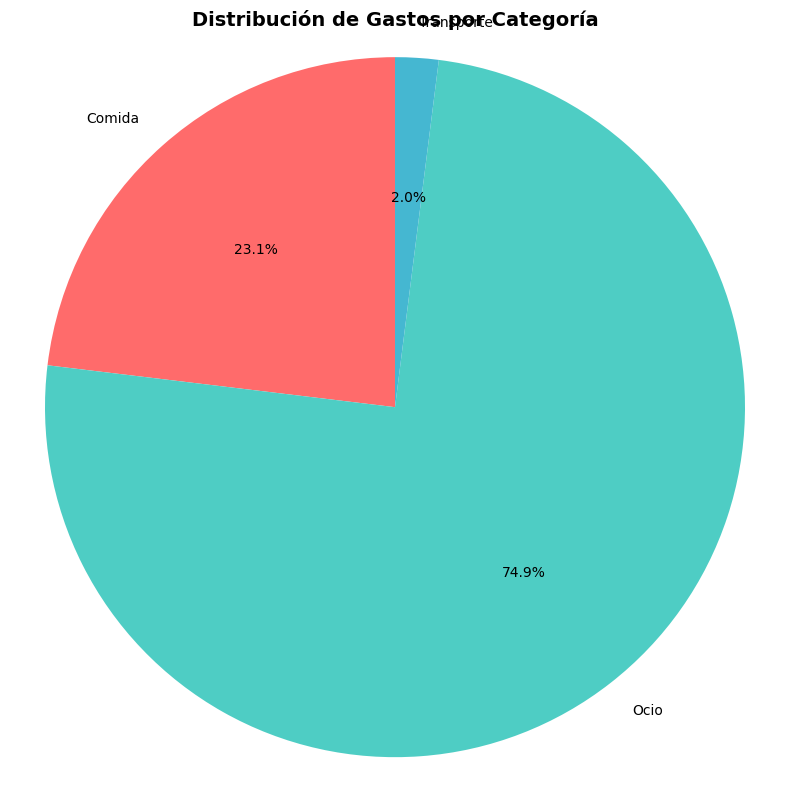

In [6]:
import numpy as np

# Generar un conjunto de datos de gastos con fechas y categorías aleatorias para simular un seguimiento de finanzas personales.
np.random.seed(42) # Se utiliza una semilla para que los resultados aleatorios sean reproducibles.
fechas = pd.date_range(start='2024-01-01', periods=10, freq='D')
categorias = np.random.choice(['Comida', 'Transporte', 'Ocio'], size=10)
gastos = np.random.randint(10, 100, size=10)

# Crear un DataFrame para organizar y analizar los datos de gastos.
df_gastos = pd.DataFrame({
    'Fecha': fechas,
    'Categoría': categorias,
    'Gasto': gastos
})

print(df_gastos)

# Calcular el gasto total para cada categoría, lo que permite entender mejor los patrones de gasto.
gasto_por_categoria = df_gastos.groupby('Categoría')['Gasto'].sum()

# Crear un gráfico de tarta para mostrar la proporción de gastos en cada categoría.
plt.figure(figsize=(8, 8))
plt.pie(gasto_por_categoria, labels=gasto_por_categoria.index, autopct='%1.1f%%', 
        startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Distribución de Gastos por Categoría', fontsize=14, fontweight='bold')
plt.axis('equal') # Asegura que el gráfico de tarta sea un círculo perfecto.
plt.tight_layout()
plt.show()

### Conexión a la Base de Datos e Inserción de Datos

En esta sección, se establece una conexión con una base de datos SQLite en memoria. Se crea una tabla `empleados` y se insertan tres registros de ejemplo. Finalmente, los datos se leen en un DataFrame de Pandas.

In [8]:
import sqlite3

# Se establece una conexión a una base de datos SQLite en memoria. Esto es útil para prototipos y pruebas, ya que no se crean archivos en disco.
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Se define y ejecuta una sentencia SQL para crear una tabla de 'empleados'. Es una buena práctica usar mayúsculas para los comandos SQL.
cursor.execute('''
CREATE TABLE empleados (
    nombre TEXT,
    departamento TEXT,
    salario INTEGER
)
''')

# Se insertan tres registros en la tabla para poblarla con datos de ejemplo.
cursor.execute("INSERT INTO empleados VALUES ('Ana García', 'Ventas', 35000)")
cursor.execute("INSERT INTO empleados VALUES ('Carlos López', 'IT', 45000)")
cursor.execute("INSERT INTO empleados VALUES ('María Rodríguez', 'Marketing', 38000)")

# Se confirman las transacciones. Sin esto, los cambios no se guardarían de forma permanente en la base de datos.
conn.commit()

# Se utiliza la biblioteca Pandas para leer los datos de la tabla 'empleados' directamente en un DataFrame, facilitando su análisis posterior.
df_empleados = pd.read_sql_query("SELECT * FROM empleados", conn)

# Es importante cerrar la conexión para liberar recursos cuando ya no se necesita.
conn.close()

print(df_empleados)

            nombre departamento  salario
0       Ana García       Ventas    35000
1     Carlos López           IT    45000
2  María Rodríguez    Marketing    38000


### Análisis de Promedios con SQL

Aquí, se crea otra base de datos en memoria para almacenar datos de ventas. Se realiza una consulta SQL para calcular el monto promedio de ventas por categoría, filtrando aquellas con un promedio superior a 100 y ordenando los resultados de forma descendente.

In [7]:
# Se crea una nueva conexión a una base de datos en memoria para un análisis de ventas por separado.
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Se crea una tabla de 'ventas' con una clave primaria que se autoincrementa, ideal para identificar cada registro de forma única.
cursor.execute('''
CREATE TABLE ventas (
    id INTEGER PRIMARY KEY,
    producto TEXT,
    categoria TEXT,
    monto INTEGER
)
''')

# Se prepara una lista de tuplas con los datos de ventas, lo que facilita la inserción masiva de registros.
ventas_data = [
    (1, 'Laptop', 'Electrónica', 1200),
    (2, 'Mouse', 'Electrónica', 25),
    (3, 'Silla', 'Muebles', 150),
    (4, 'Escritorio', 'Muebles', 350),
    (5, 'Teclado', 'Electrónica', 80),
    (6, 'Monitor', 'Electrónica', 300),
    (7, 'Lámpara', 'Iluminación', 45),
    (8, 'Estantería', 'Muebles', 200),
    (9, 'Cable USB', 'Electrónica', 10),
    (10, 'Bombilla LED', 'Iluminación', 15)
]

# Se utiliza 'executemany' para insertar todos los registros de la lista de una sola vez, una forma mucho más eficiente que múltiples 'execute'.
cursor.executemany("INSERT INTO ventas VALUES (?, ?, ?, ?)", ventas_data)
conn.commit()

# Se ejecuta una consulta SQL compleja para obtener información de negocio:
# - SELECT categoria, AVG(monto): Se seleccionan las categorías y se calcula el promedio de sus montos.
# - FROM ventas: Se especifican los datos de origen.
# - GROUP BY categoria: Se agrupan las filas por categoría para que AVG() funcione sobre cada grupo.
# - HAVING AVG(monto) > 100: Se filtran los grupos, mostrando solo aquellos cuyo promedio de monto es mayor a 100.
# - ORDER BY promedio_monto DESC: Se ordenan los resultados de mayor a menor promedio.
df_promedio_ventas = pd.read_sql_query(
    "SELECT categoria, AVG(monto) as promedio_monto FROM ventas GROUP BY categoria HAVING AVG(monto) > 100 ORDER BY promedio_monto DESC",
    conn
)

print(df_promedio_ventas)

     categoria  promedio_monto
0  Electrónica      323.000000
1      Muebles      233.333333
